# EXFOR `to_plot_data()` Demo

This notebook demonstrates the `to_plot_data()` method for EXFOR angular distributions,
which enables seamless integration with kika's `PlotBuilder` architecture.

## Key Features

- **PlotBuilder Integration**: Returns `AngularDistributionPlotData` compatible with `PlotBuilder.add_data()`
- **Error Bars**: Automatically includes error bars when `uncertainty=True` (default)
- **Frame Conversion**: Easy LAB ↔ CM frame conversion
- **Unit Flexibility**: Support for cosine or degree angles, b/sr or mb/sr cross sections
- **Connect Points**: Optional line connection between data points

## 1. Setup and Loading Data

In [1]:
import kika.exfor as exfor
from kika.exfor import X4ProDatabase, read_all_exfor
from kika.plotting import PlotBuilder
import matplotlib.pyplot as plt
import numpy as np

exfor.configure(db_path=r"C:\Users\Usuario\BaradDur\EXFOR\x4sqlite-20251105-c\x4sqlite1.db")

# Connect to database
db = X4ProDatabase()

# Load a well-known Fe-56 experiment (Kinney 1976)
exfor = db.load_experiment("10571002")

print(f"Experiment: {exfor.label}")
print(f"Target: {exfor.target} (ZAID: {exfor.zaid})")
print(f"Process: {exfor.process}")
print(f"Frame: {exfor.angle_frame}")
print(f"Energy range: {exfor.energies().min():.2f} - {exfor.energies().max():.2f} MeV")
print(f"Number of energy points: {len(exfor.energies())}")

Experiment: Kinney (1976)
Target: Fe (ZAID: 26000)
Process: EL
Frame: LAB
Energy range: 0.50 - 2.50 MeV
Number of energy points: 2001


## 2. Basic Usage - Single Energy with PlotBuilder

The `to_plot_data()` method returns data compatible with `PlotBuilder.add_data()`.
By default, it returns a tuple `(PlotData, None)` where PlotData contains error information.

In [2]:
# Get plot data at 1.5 MeV (use tight tolerance to get single energy)
plot_data = exfor.to_plot_data(energy=1.5, tolerance=0.01)

# Inspect returned data
print(f"Type: {type(plot_data)}")
print(f"\nReturned tuple with:")
print(f"  - PlotData: {type(plot_data[0]).__name__}")
print(f"  - Second element: {plot_data[1]}")

# Look at PlotData attributes
pd = plot_data[0]
print(f"\nPlotData attributes:")
print(f"  x (angles): {pd.x[:5]}... ({len(pd.x)} points)")
print(f"  y (cross sections): {pd.y[:5]}...")
print(f"  label: {pd.label}")
print(f"  energy: {pd.energy}")
print(f"  plot_type: {pd.plot_type}")
print(f"  yerr in metadata: {'yerr' in pd.metadata}")

Type: <class 'tuple'>

Returned tuple with:
  - PlotData: AngularDistributionPlotData
  - Second element: None

PlotData attributes:
  x (angles): [-0.90945395 -0.77339784 -0.58552376 -0.01780142  0.32622817]... (8 points)
  y (cross sections): [0.134 0.113 0.102 0.056 0.048]...
  label: Kinney (1976) [nat]
  energy: 1.5
  plot_type: errorbar
  yerr in metadata: True


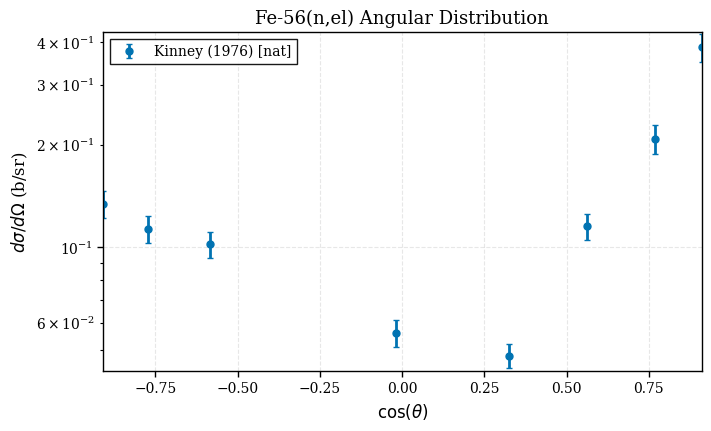

In [3]:
# Plot using PlotBuilder
fig = (
    PlotBuilder(figsize=(10, 6))
    .add_data(plot_data)
    .set_labels(
        title="Fe-56(n,el) Angular Distribution",
        x_label=r"$\cos(\theta)$",
        y_label=r"$d\sigma/d\Omega$ (b/sr)"
    )
    .set_scales(log_y=True)
    .build()
)
plt.show()

## 3. Error Bar Options

By default, `uncertainty=True` shows error bars. Use `uncertainty=False` for scatter-only plots.

C:\Users\Usuario\AppData\Local\Temp\ipykernel_59068\2254930010.py:18: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


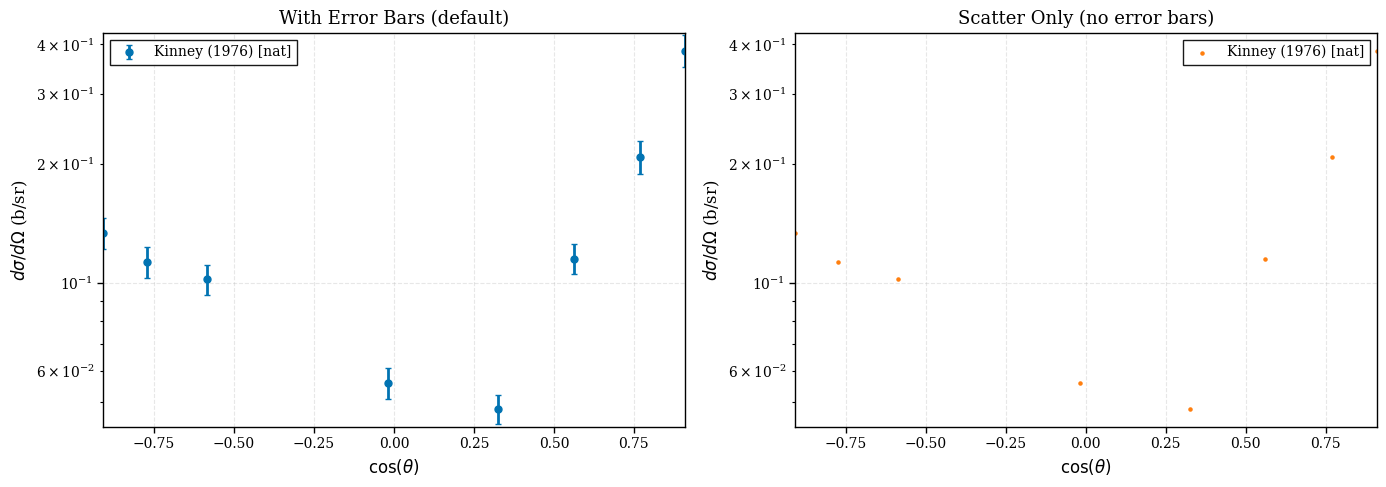

In [4]:
# Compare with and without error bars
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# With error bars (default)
builder1 = PlotBuilder(ax=ax1)
builder1.add_data(exfor.to_plot_data(energy=1.5, tolerance=0.01, uncertainty=True))
builder1.set_labels(title="With Error Bars (default)", x_label=r"$\cos(\theta)$", y_label=r"$d\sigma/d\Omega$ (b/sr)")
builder1.set_scales(log_y=True)
builder1.build()

# Without error bars (scatter only)
builder2 = PlotBuilder(ax=ax2)
builder2.add_data(exfor.to_plot_data(energy=1.5, tolerance=0.01, uncertainty=False, color='C1'))
builder2.set_labels(title="Scatter Only (no error bars)", x_label=r"$\cos(\theta)$", y_label=r"$d\sigma/d\Omega$ (b/sr)")
builder2.set_scales(log_y=True)
builder2.build()

plt.tight_layout()
plt.show()

## 4. Connecting Points with Lines

Use `connect_points=True` to connect data points with lines.

C:\Users\Usuario\AppData\Local\Temp\ipykernel_59068\1664640328.py:18: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


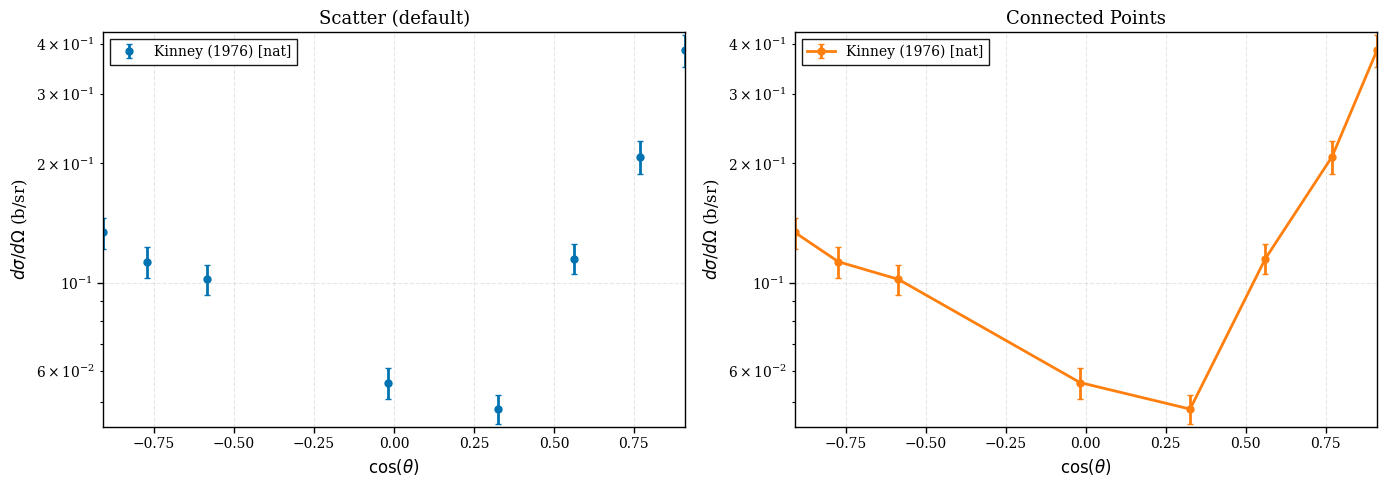

In [5]:
# Compare scatter vs connected
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Scatter (default)
builder1 = PlotBuilder(ax=ax1)
builder1.add_data(exfor.to_plot_data(energy=1.5, tolerance=0.01, connect_points=False))
builder1.set_labels(title="Scatter (default)", x_label=r"$\cos(\theta)$", y_label=r"$d\sigma/d\Omega$ (b/sr)")
builder1.set_scales(log_y=True)
builder1.build()

# Connected
builder2 = PlotBuilder(ax=ax2)
builder2.add_data(exfor.to_plot_data(energy=1.5, tolerance=0.01, connect_points=True, color='C1'))
builder2.set_labels(title="Connected Points", x_label=r"$\cos(\theta)$", y_label=r"$d\sigma/d\Omega$ (b/sr)")
builder2.set_scales(log_y=True)
builder2.build()

plt.tight_layout()
plt.show()

## 5. Frame Conversion (LAB vs CM)

EXFOR data may be in LAB or CM frame. Use the `frame` parameter to convert.

In [6]:
# Check current frame
print(f"Original data frame: {exfor.angle_frame}")

# Get data in both frames
plot_lab = exfor.to_plot_data(energy=1.5, tolerance=0.01, frame='LAB', uncertainty=False, color='C0', label='LAB frame')
plot_cm = exfor.to_plot_data(energy=1.5, tolerance=0.01, frame='CM', uncertainty=False, color='C1', label='CM frame')

print(f"LAB plot label: {plot_lab.label}")
print(f"CM plot label: {plot_cm.label}")

Original data frame: LAB
LAB plot label: LAB frame
CM plot label: CM frame


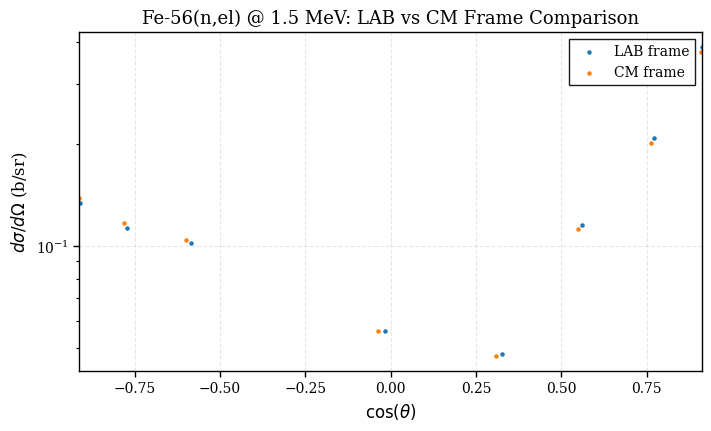

In [7]:
# Compare LAB and CM frames
fig = (
    PlotBuilder(figsize=(10, 6))
    .add_data(plot_lab)
    .add_data(plot_cm)
    .set_labels(
        title="Fe-56(n,el) @ 1.5 MeV: LAB vs CM Frame Comparison",
        x_label=r"$\cos(\theta)$",
        y_label=r"$d\sigma/d\Omega$ (b/sr)"
    )
    .set_scales(log_y=True)
    .set_legend(loc='upper right')
    .build()
)
plt.show()

## 6. Angle Units

By default, angles are in cosine (μ). Use `angle_unit='deg'` for degrees.

C:\Users\Usuario\AppData\Local\Temp\ipykernel_59068\2422185967.py:18: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


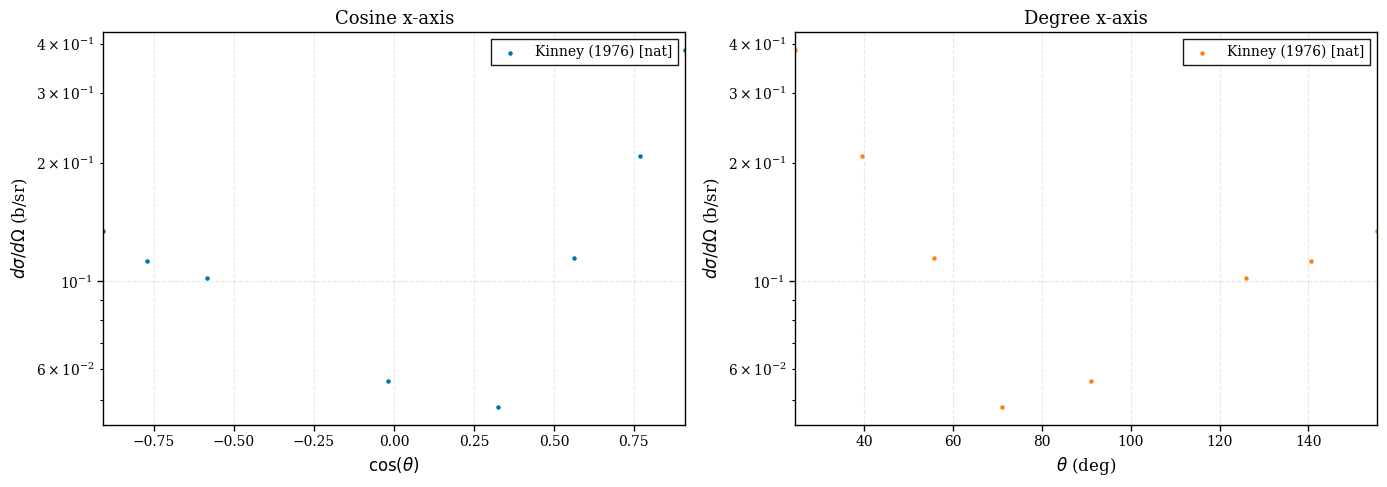

In [8]:
# Compare cosine vs degree x-axis
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Cosine (default)
builder1 = PlotBuilder(ax=ax1)
builder1.add_data(exfor.to_plot_data(energy=1.5, tolerance=0.01, angle_unit='cos', uncertainty=False))
builder1.set_labels(title="Cosine x-axis", x_label=r"$\cos(\theta)$", y_label=r"$d\sigma/d\Omega$ (b/sr)")
builder1.set_scales(log_y=True)
builder1.build()

# Degrees
builder2 = PlotBuilder(ax=ax2)
builder2.add_data(exfor.to_plot_data(energy=1.5, tolerance=0.01, angle_unit='deg', uncertainty=False, color='C1'))
builder2.set_labels(title="Degree x-axis", x_label=r"$\theta$ (deg)", y_label=r"$d\sigma/d\Omega$ (b/sr)")
builder2.set_scales(log_y=True)
builder2.build()

plt.tight_layout()
plt.show()

## 7. Styling Options

Pass styling kwargs to customize markers, colors, etc.

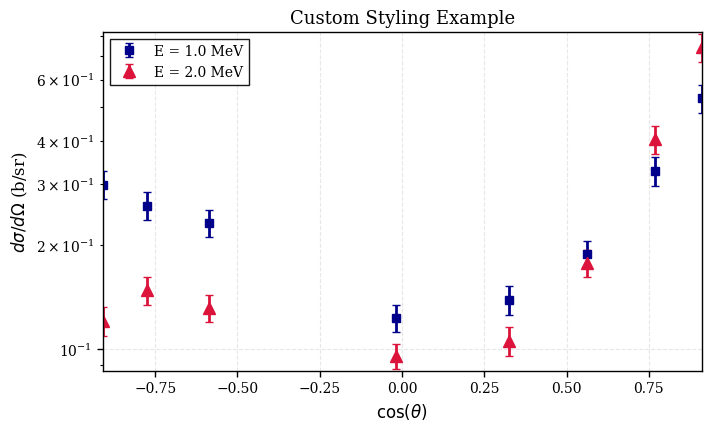

In [9]:
# Custom styling
fig = (
    PlotBuilder(figsize=(10, 6))
    .add_data(exfor.to_plot_data(
        energy=1.0, 
        tolerance=0.01,
        uncertainty=True,
        color='darkblue',
        marker='s',
        markersize=6,
        capsize=3,
        label='E = 1.0 MeV'
    ))
    .add_data(exfor.to_plot_data(
        energy=2.0, 
        tolerance=0.01,
        uncertainty=True,
        color='crimson',
        marker='^',
        markersize=8,
        capsize=3,
        label='E = 2.0 MeV'
    ))
    .set_labels(
        title="Custom Styling Example",
        x_label=r"$\cos(\theta)$",
        y_label=r"$d\sigma/d\Omega$ (b/sr)"
    )
    .set_scales(log_y=True)
    .build()
)
plt.show()

## 8. Comparing Multiple Experiments

Load data from different experiments and compare them.

In [10]:
# Find experiments at similar energies
data_by_energy = read_all_exfor(target="Fe56", mt=2)

# Find energies close to 1.5 MeV
target_e = 1.5
energies = sorted(data_by_energy.keys())
close_energies = [e for e in energies if abs(e - target_e) < 0.1]

print(f"Energies near {target_e} MeV: {close_energies[:5]}...")
if close_energies:
    closest = min(close_energies, key=lambda e: abs(e - target_e))
    experiments = data_by_energy[closest]
    print(f"\nExperiments at E={closest:.3f} MeV:")
    for exp in experiments:
        print(f"  - {exp.label} (frame: {exp.angle_frame})")

Energies near 1.5 MeV: [np.float64(1.5)]...

Experiments at E=1.500 MeV:
  - Ramirez (2017) (frame: LAB)


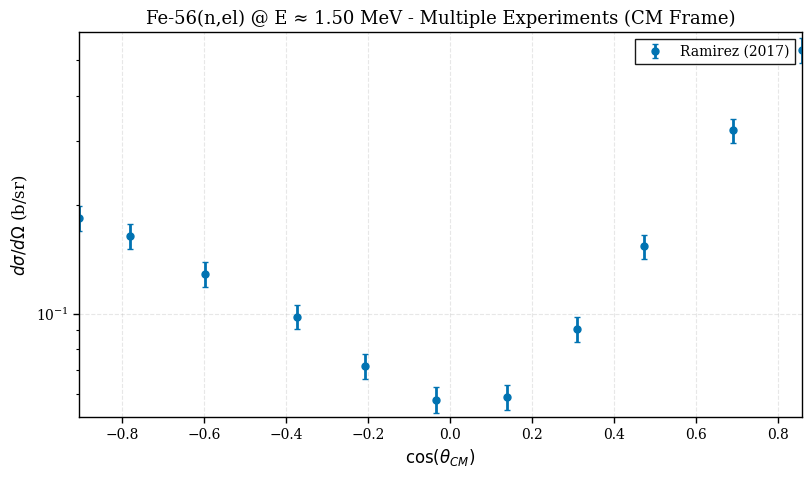

In [11]:
# Plot multiple experiments at same energy
if close_energies:
    builder = PlotBuilder(figsize=(12, 7))
    
    for i, exp in enumerate(experiments[:5]):  # Limit to 5 experiments
        try:
            plot_data = exp.to_plot_data(
                energy=closest,
                tolerance=0.02,
                frame='CM',  # Convert all to CM for comparison
                uncertainty=True
            )
            builder.add_data(plot_data)
        except ValueError as e:
            print(f"Skipping {exp.label}: {e}")
    
    fig = (
        builder
        .set_labels(
            title=f"Fe-56(n,el) @ E ≈ {closest:.2f} MeV - Multiple Experiments (CM Frame)",
            x_label=r"$\cos(\theta_{CM})$",
            y_label=r"$d\sigma/d\Omega$ (b/sr)"
        )
        .set_scales(log_y=True)
        .set_legend(loc='upper right')
        .build()
    )
    plt.show()

## 9. Comprehensive Comparison: All Experiments at a Specific Energy

This example shows how to plot **all available experimental data** for Fe-56 (or natural Fe) 
elastic scattering at a specific energy, with uncertainties, all converted to CM frame.

This is a practical use case for comparing different experimental measurements.

In [17]:
# Configuration
TARGET_ENERGY = 1.3099  # MeV
ENERGY_TOLERANCE = 0.01  # MeV (10 keV) - absolute tolerance

# Load all experiments WITHOUT grouping by energy
# This gives us unique experiments (one per entry/subentry)
print("Loading Fe-56 elastic scattering data...")
fe56_experiments = read_all_exfor(target="Fe56", mt=2, group_by_energy=False, source='auto')

print("Loading natural Fe elastic scattering data...")
fe_nat_experiments = read_all_exfor(target="Fe", mt=2, group_by_energy=False)

print(f"\nFe-56: {len(fe56_experiments)} unique experiments")
print(f"Fe-nat: {len(fe_nat_experiments)} unique experiments")

Loading Fe-56 elastic scattering data...
Loading natural Fe elastic scattering data...

Fe-56: 16 unique experiments
Fe-nat: 103 unique experiments


In [18]:
def find_experiments_with_data_near_energy(experiments_dict, target_e, tolerance):
    """
    Find experiments that have at least one data point near target energy.

    Parameters:
        experiments_dict: Dict[str, ExforAngularDistribution] from read_all_exfor(group_by_energy=False)
        target_e: Target energy in MeV
        tolerance: Absolute tolerance in MeV

    Returns:
        List of unique ExforAngularDistribution objects
    """
    matching = []
    for exp_id, exp in experiments_dict.items():
        energies = exp.energies(unit="MeV")
        # Check if any energy is within tolerance
        if np.any(np.abs(energies - target_e) <= tolerance):
            matching.append(exp)
    return matching

# Find experiments with data near TARGET_ENERGY
fe56_near = find_experiments_with_data_near_energy(fe56_experiments, TARGET_ENERGY, ENERGY_TOLERANCE)
fe_nat_near = find_experiments_with_data_near_energy(fe_nat_experiments, TARGET_ENERGY, ENERGY_TOLERANCE)

print(f"Experiments with data near {TARGET_ENERGY} MeV (±{ENERGY_TOLERANCE*1000:.0f} keV):")
print(f"  Fe-56: {len(fe56_near)} experiments")
print(f"  Fe-nat: {len(fe_nat_near)} experiments")

# Show details
print(f"\nFe-56 experiments:")
for exp in fe56_near:
    nat_tag = "[nat]" if exp.is_natural_target else ""
    print(f"  {exp.entry}/{exp.subentry}: {exp.label} {nat_tag}")

print(f"\nFe-nat experiments:")
for exp in fe_nat_near:
    nat_tag = "[nat]" if exp.is_natural_target else ""
    print(f"  {exp.entry}/{exp.subentry}: {exp.label} {nat_tag}")

Experiments with data near 1.3099 MeV (±10 keV):
  Fe-56: 1 experiments
  Fe-nat: 3 experiments

Fe-56 experiments:
  14462/002: Ramirez (2017) 

Fe-nat experiments:
  10571/002: Kinney (1976) [nat]
  20197/006: Malmskog (1972) [nat]
  20743/002: Cierjacks (1978) [nat]


C:\Users\Usuario\AppData\Local\Temp\ipykernel_59068\3382292971.py:48: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


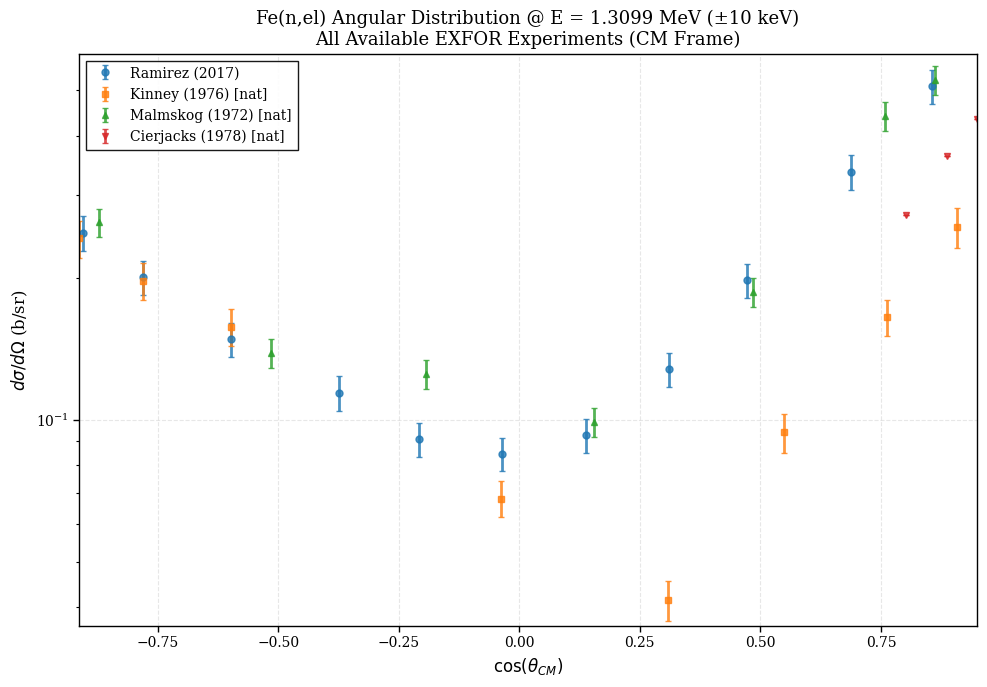


Plotted 4 experiments


In [19]:
# Create comparison plot
fig, ax = plt.subplots(figsize=(10, 7))
builder = PlotBuilder(ax=ax)

markers = ['o', 's', '^', 'v', 'D', 'p', 'h', '*', 'X', 'P']
colors = plt.cm.tab10.colors

plotted_count = 0
skipped = []

# Combine all unique experiments
all_experiments = fe56_near + fe_nat_near

# Plot each experiment ONCE
for exp in all_experiments:
    plot_data = exp.to_plot_data(
        energy=TARGET_ENERGY,
        tolerance=ENERGY_TOLERANCE,
        frame='CM',
        uncertainty=True,
        include_natural_tag=True,
        marker=markers[plotted_count % len(markers)],
        color=colors[plotted_count % len(colors)],
        markersize=5,
        capsize=2,
        alpha=0.8,
    )

    if plot_data is not None:
        builder.add_data(plot_data)
        plotted_count += 1
    else:
        skipped.append((exp.label, "No data within tolerance"))

# Build the plot
fig = (
    builder
    .set_labels(
        title=f"Fe(n,el) Angular Distribution @ E = {TARGET_ENERGY} MeV (±{ENERGY_TOLERANCE*1000:.0f} keV)\nAll Available EXFOR Experiments (CM Frame)",
        x_label=r"$\cos(\theta_{CM})$",
        y_label=r"$d\sigma/d\Omega$ (b/sr)"
    )
    .set_scales(log_y=True)
    .set_legend(loc='upper left')
    .build()
)

plt.tight_layout()
plt.show()

print(f"\nPlotted {plotted_count} experiments")
if skipped:
    print(f"Skipped {len(skipped)} experiments:")
    for name, reason in skipped:
        print(f"  - {name}: {reason}")

In [20]:
# Cleanup
db.close()
print("Database connection closed.")

Database connection closed.
